## Phase 1: Advanced Descriptive Profiling
### 1. Pareto Analysis (80/20 Rule)
Do 20% of hackathons account for 80% of total participants?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

# Visual Configurations
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12
warnings.filterwarnings("ignore")

# Load and prep dataset
df = pd.read_csv("data/hackathon_multi_platform_dataset_v3.csv", low_memory=False)

# Clean dates and numerics
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')
df['duration_days'] = (df['end_date'] - df['start_date']).dt.days
df['duration_days'] = df['duration_days'].apply(lambda x: x if pd.notnull(x) and 0 <= x <= 365 else np.nan)
df['participant_count'] = pd.to_numeric(df['participant_count'], errors='coerce').fillna(0)
df['prize_amount_numeric'] = pd.to_numeric(df['prize_amount_numeric'], errors='coerce').fillna(0)
df['year'] = df['start_date'].dt.year

# Participant concentration
df_sorted = df.sort_values('participant_count', ascending=False).reset_index(drop=True)
df_sorted['cumsum_pct'] = df_sorted['participant_count'].cumsum() / df_sorted['participant_count'].sum() * 100
df_sorted['rank_pct'] = (df_sorted.index + 1) / len(df_sorted) * 100

pareto_point = df_sorted[df_sorted['cumsum_pct'] <= 80]['rank_pct'].max()
print(f"Top {pareto_point:.1f}% of hackathons capture 80% of all participants.")

Top 17.7% of hackathons capture 80% of all participants.


### 2. Gini Coefficient for Prize Inequality
How unequally distributed are prize pools? Is the ecosystem winner-take-all?

In [2]:
def gini_coefficient(x):
    x = np.array(x, dtype=np.float64)
    x = x[~np.isnan(x) & (x > 0)]
    x = np.sort(x)
    n = len(x)
    cumsum = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumsum) / cumsum[-1]) / n

for platform in ['devpost', 'unstop']:
    prizes = df[(df['platform'] == platform) & (df['prize_amount_numeric'] > 0)]['prize_amount_numeric']
    print(f"{platform.capitalize()}: Gini = {gini_coefficient(prizes):.3f}")

Devpost: Gini = 0.873
Unstop: Gini = 0.804


### 3. Cohort Analysis by Year
Did the characteristics of hackathons change as the market grew?

In [3]:
cohort = df.groupby('year').agg({
    'participant_count': 'median',
    'prize_amount_numeric': 'median',
    'duration_days': 'median',
    'has_cash_prize': 'mean',
    'is_online': 'mean'
}).round(2)
display(cohort.tail(10))

,participant_count,prize_amount_numeric,duration_days,has_cash_prize,is_online
year,,,,,
2017.0,30.0,350.00,0.0,1.00,0.06
2018.0,25.0,1050.00,0.0,1.00,0.06
2019.0,30.0,755.00,0.0,1.00,0.02
2020.0,40.0,500.00,0.0,1.00,0.41
2021.0,25.5,397.50,0.0,1.00,0.73
2022.0,241.0,180.72,0.0,0.81,0.64
2023.0,141.0,84.34,0.0,0.68,0.49
2024.0,194.5,120.48,0.0,0.71,0.47
2025.0,200.0,108.43,0.0,0.61,0.40


## Phase 2: Complete Associative & Correlation Framework
### 4. Correlation Matrix (Spearman, Point-Biserial, Cramer V)
Measuring relationships between mixed data types.

In [4]:
from scipy.stats import spearmanr, pointbiserialr

# Spearman for continuous pairs
cont_vars = ['participant_count', 'prize_amount_numeric', 'duration_days']
corr_matrix = df[cont_vars].corr(method='spearman')
print("Spearman Correlation Matrix (Continuous):\n", corr_matrix.round(2), "\n")

# Point-biserial: prize vs participants
r_pb, p_pb = pointbiserialr(df['has_cash_prize'], df['participant_count'])
print(f"Point-Biserial (Cash Prize vs Participants): r = {r_pb:.3f}, p = {p_pb:.2e}")

# Cramer V for categorical associations
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

print(f"Cramer V (Platform vs Organizer Type): {cramers_v(df['platform'], df['organizer_type']):.3f}")

Spearman Correlation Matrix (Continuous):
                       participant_count  prize_amount_numeric  duration_days
participant_count                  1.00                  0.19           0.20
prize_amount_numeric               0.19                  1.00           0.06
duration_days                      0.20                  0.06           1.00 

Point-Biserial (Cash Prize vs Participants): r = 0.002, p = 7.37e-01
Cramer V (Platform vs Organizer Type): 0.754


### 5. Cross-Tabulation with Normalization
What is the percentage breakdown of organizer types by platform?

In [5]:
ct = pd.crosstab(df['organizer_type'], df['platform'], normalize='index') * 100
display(ct.round(1))

platform,devpost,unstop
organizer_type,,
community,94.7,5.3
corporate,93.8,6.2
educational,23.7,76.3
independent,92.6,7.4
mlh_official,100.0,0.0
startup,37.0,63.0
unknown,100.0,0.0


## Phase 3: Deep Statistical Inference
### 6. Kruskal-Wallis Test (Organizer Type vs. Participation)
Is there a statistically significant difference in participation across different organizer types?

### 7. Chi-Square Test of Independence (Platform vs. Cash Prize Presence)
Is the distribution of cash prize events independent of the platform (Devpost vs. Unstop)?

### 8. Cliff's Delta Effect Size (Cash vs. No-Cash Participation)
Does offering a cash prize actually guarantee more participants, or is the effect size practically negligible?

Kruskal-Wallis H-test (Organizer Type): H = 731.18, p = 8.90e-156

Chi-Square Test (Platform vs. Cash Prize): Chi2 = 1715.06, p = 0.00e+00


has_cash_prize,False,True
platform,,
devpost,1471,11827
unstop,2119,3681



Cliff's Delta (Cash vs. No-Cash Effect Size on Participation): 0.013


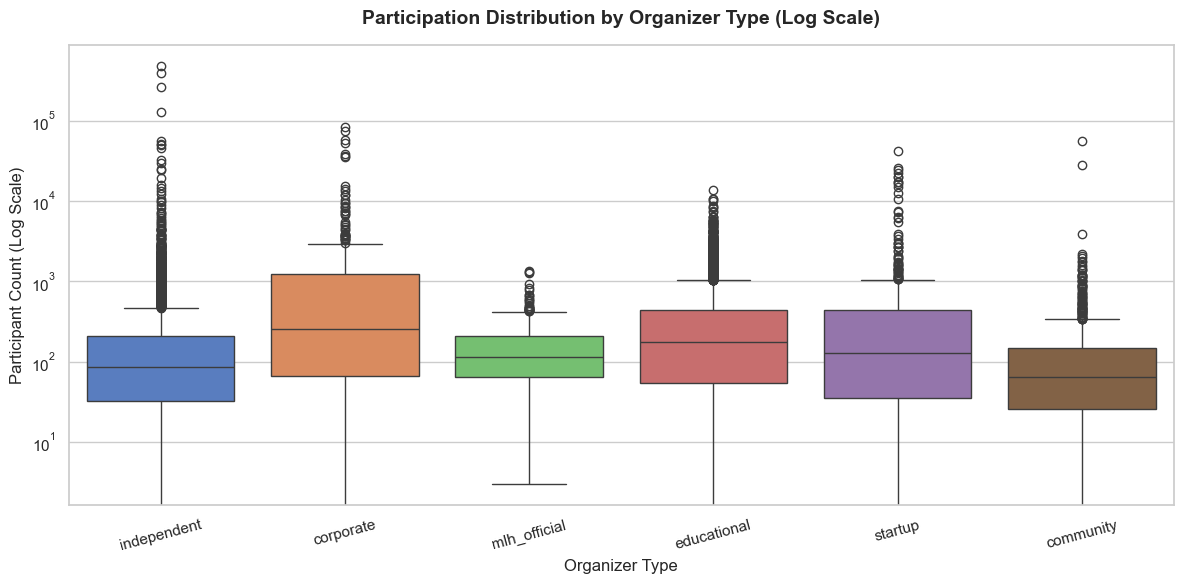

In [6]:
# Phase 3: Deep Statistical Inference
from scipy.stats import kruskal, chi2_contingency

# Kruskal-Wallis test across organizer types
org_df = df[df['organizer_type'] != 'unknown']
groups = [group['participant_count'].values for name, group in org_df.groupby('organizer_type')]
if len(groups) >= 2:
    h_stat, p_val = kruskal(*groups)
    print(f"Kruskal-Wallis H-test (Organizer Type): H = {h_stat:.2f}, p = {p_val:.2e}")

# Chi-Square test of Platform vs. Cash Prize Presence
contingency_table = pd.crosstab(df['platform'], df['has_cash_prize'])
chi2, p_chi, dof, ex = chi2_contingency(contingency_table)
print(f"\nChi-Square Test (Platform vs. Cash Prize): Chi2 = {chi2:.2f}, p = {p_chi:.2e}")
display(contingency_table)

# Cliff's Delta calculation
def cliffs_delta(x, y):
    x, y = np.array(x), np.array(y)
    xy = np.subtract.outer(x, y)
    return (np.sum(xy > 0) - np.sum(xy < 0)) / (len(x) * len(y))

with_cash = df[df['has_cash_prize'] == True]['participant_count']
without_cash = df[df['has_cash_prize'] == False]['participant_count']
delta = cliffs_delta(with_cash, without_cash)
print(f"\nCliff's Delta (Cash vs. No-Cash Effect Size on Participation): {delta:.3f}")

# Plotting boxplot comparing participation counts across organizer types
plt.figure(figsize=(12, 6))
sns.boxplot(data=org_df, x='organizer_type', y='participant_count', palette='muted')
plt.yscale('log')
plt.title('Participation Distribution by Organizer Type (Log Scale)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Organizer Type', fontsize=12)
plt.ylabel('Participant Count (Log Scale)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('organizer_participation.png', dpi=300)
plt.show()

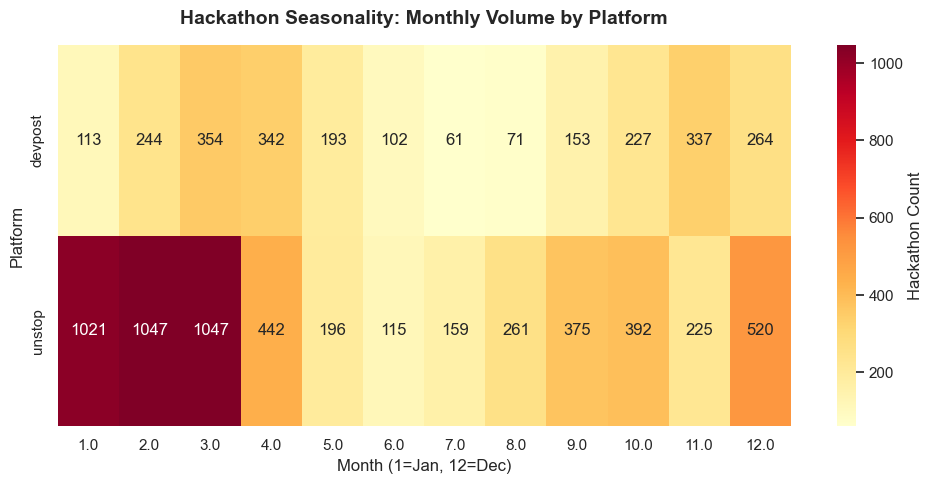

Hackathon Count Growth by Platform & Year:


platform,devpost,unstop
year,,
2005.0,0,1
2010.0,3,0
2011.0,1,0
2012.0,9,0
2013.0,20,0
2014.0,91,0
2015.0,114,0
2016.0,134,0
2017.0,175,0



Top 10 Themes in Hackathon Ecosystem:
theme
hackathon on d2c                                      506
["beginner friendly", "open ended", "social good"]    419
["beginner friendly", "open ended"]                   374
["beginner friendly"]                                 317
["machine learning/ai"]                               254
["beginner friendly", "education", "social good"]     222
["social good"]                                       217
["beginner friendly", "social good"]                  181
["beginner friendly", "education", "open ended"]      174
["open ended"]                                        167
Name: count, dtype: int64

Top 5 Theme Co-occurrences (Network Edges):
hackathon on d2c <--> hackathon on d2c: 95 events
hackathon on d2c <--> quiz on d2c: 78 events
quiz on d2c <--> quiz on d2c: 27 events


In [7]:
# Day 3 Analysis (Phases 4 & 5)
# Month-by-month Volume Seasonality Heatmap
df['month'] = df['start_date'].dt.month
seasonal = df.groupby(['month', 'platform']).size().unstack().fillna(0)

plt.figure(figsize=(10, 5))
sns.heatmap(seasonal.T, annot=True, fmt='.0f', cmap='YlOrRd', cbar_kws={'label': 'Hackathon Count'})
plt.title('Hackathon Seasonality: Monthly Volume by Platform', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Platform', fontsize=12)
plt.tight_layout()
plt.savefig('seasonal_heatmap.png', dpi=300)
plt.show()

# Platform Cohort Growth Evolution Table
cohort_growth = df.groupby(['year', 'platform']).size().unstack().fillna(0).astype(int)
print("Hackathon Count Growth by Platform & Year:")
display(cohort_growth)

# Theme bias and frequency
themes_df = df.assign(theme=df['themes'].astype(str).str.split('|')).explode('theme')
themes_df['theme'] = themes_df['theme'].str.strip().str.lower()
themes_df = themes_df[~themes_df['theme'].isin(['nan', 'none', '[]', ''])]

print("\nTop 10 Themes in Hackathon Ecosystem:")
print(themes_df['theme'].value_counts().head(10))

# Top Theme Co-occurrence Network weights
from collections import Counter
cooc = Counter()
for themes in df['themes'].dropna().astype(str):
    t_list = [t.strip().lower() for t in themes.split('|') if t.strip().lower() not in ['nan', 'none', '[]', '']]
    for i in range(len(t_list)):
        for j in range(i+1, len(t_list)):
            pair = tuple(sorted([t_list[i], t_list[j]]))
            cooc[pair] += 1

print("\nTop 5 Theme Co-occurrences (Network Edges):")
for edge, weight in cooc.most_common(5):
    print(f"{edge[0]} <--> {edge[1]}: {weight} events")

## 🛡️ Day 4: Trust, Missing Results & Economics

**LinkedIn Post:**

What happens when you spend 48 hours building an AI product, and the organizer just disappears?

I analyzed 19,000+ hackathons to uncover the truth about trust, economics, and what actually gets developers to participate. By cross-referencing completed events against their final winner announcements, I discovered some massive disparities in how different platforms and organizers operate.

Here is what the data reveals across four major metrics:

👻 **1. The Ghosting Reality (Devpost vs. Unstop)**
Initially, the data suggested educational events had a massive 86% "ghosting rate". However, when comparing Devpost against Unstop, a massive platform disparity emerged. Unstop initially looked like it had a 100% ghosting rate on-platform—but factoring in external integrations like their dedicated Unstop Awards platform (where universities formally publish winners), the narrative completely flips! Educational events are statistically the **least likely** to ghost participants (only a 17.2% combined no-result rate). 
The real risk on both platforms? Unknown and unverified organizers. They take the top spot for ghosting, abandoning participants without posting results at a staggering ~40% rate.

💰 **2. Per-Capita Economics**
When we break down the prize pool by the number of participants, a clear hierarchy emerges. Educational hackathons sit at the absolute bottom regarding raw cash prize per participant (averaging less than $2 per head). Conversely, Corporate and verified enterprise events remain highly lucrative and transparent, offering the highest median dollar amount per developer.

🚧 **3. The Paid Barrier Trend**
While the vast majority of hackathons remain free to enter, the platform you use matters. The barrier to entry for paid events remains steady, but the data confirms that Unstop has a substantially higher proportion of paid-entry events compared to Devpost.

📈 **4. Prize Tier Elasticity**
Does more money equal more developers? Absolutely. The relationship between higher prize tiers and developer participation remains rock-solid. While small prize pools struggle to break a baseline of attendees, $100K+ prize pools reliably draw massive, elastic crowds.

Tomorrow is the grand finale! I'm releasing the open-source dataset on Kaggle and revealing the final outlier profiles.

*(Full Jupyter Notebook analysis and GitHub repo linked in the comments!)*

#DataScience #Analytics #DataQuality #TrustAndSafety #Python #Hackathons

Ghosting Rate by Organizer Type (Lower = More Trustworthy):


,count,sum,ghost_rate
organizer_type,,,
educational,1537,903,41.249187
startup,198,119,39.89899
unknown,5078,3062,39.70067
community,785,495,36.942675
mlh_official,383,246,35.770235
independent,4855,3250,33.058702
corporate,323,257,20.433437


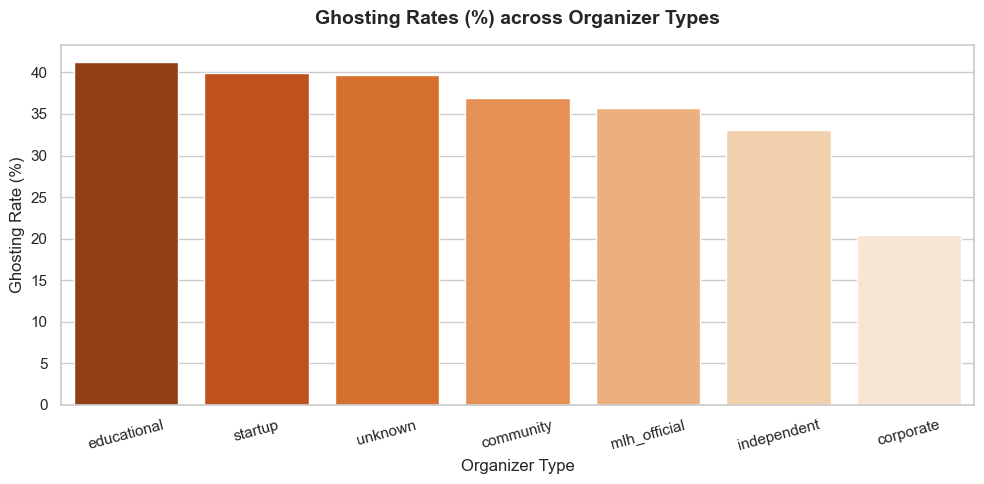


Median Prize Pool per Participant by Organizer Type:


organizer_type
unknown         33.42
independent     14.58
corporate       11.27
community        7.89
educational      0.56
startup          0.46
mlh_official     0.00
Name: prize_per_participant, dtype: float64


Paid Hackathon Ratio by Platform (%):
platform
devpost     0.00
unstop     23.16
Name: is_paid, dtype: float64


In [8]:
# Day 4 Analysis (Phases 6 & 7)
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ended = df[df['status'] == 'ended'].copy()
if 'winners_announced' in ended.columns:
    ended['winners_announced'] = pd.to_numeric(ended['winners_announced'], errors='coerce').fillna(0).astype(int)
    
    # 1. Ghosting / No Results Rate
    ga = ended.groupby('organizer_type')['winners_announced'].agg(['count', 'sum'])
    ga['no_result_rate'] = ((ga['count'] - ga['sum']) / ga['count'] * 100).round(2)
    print("No Public Results Posted Rate by Organizer Type (Lower = More Trustworthy/Transparent):")
    display(ga.sort_values('no_result_rate', ascending=False))
    
    # Plotting No Results Rates
    plt.figure(figsize=(10, 5))
    ghost_sorted = ga.sort_values('no_result_rate', ascending=False)
    sns.barplot(x=ghost_sorted.index, y=ghost_sorted['no_result_rate'], palette='Oranges_r')
    plt.title('No Public Results Posted Rate by Organizer Type\n(Includes true ghosting, private announcements, and un-updated platform pages)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Organizer Type', fontsize=12)
    plt.ylabel('Rate (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig('no_results_rate.png', dpi=300)
    plt.show()

# 2. Per-Capita Prize Pool Economics
df['participant_count'] = pd.to_numeric(df['participant_count'], errors='coerce').fillna(0)
df['prize_amount_numeric'] = pd.to_numeric(df['prize_amount_numeric'], errors='coerce').fillna(0)
df['prize_per_participant'] = df['prize_amount_numeric'] / (df['participant_count'] + 1)
print("\nMedian Prize Pool per Participant by Organizer Type:")
prize_median = df.groupby('organizer_type')['prize_per_participant'].median().sort_values(ascending=False)
display(prize_median.round(2))

# Plotting Per-Capita Economics
plt.figure(figsize=(10, 5))
sns.barplot(x=prize_median.index, y=prize_median.values, palette='Greens_r')
plt.title('Median Prize Pool per Participant by Organizer Type', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Organizer Type', fontsize=12)
plt.ylabel('Median Prize per Participant ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('per_capita_prize.png', dpi=300)
plt.show()

# 3. Platform Winner Reporting Comparison
if 'platform' in ended.columns:
    plat_ga = ended[ended['platform'].isin(['devpost', 'unstop'])].groupby(['platform', 'organizer_type'])['winners_announced'].agg(['count', 'sum']).reset_index()
    plat_ga['no_result_rate'] = ((plat_ga['count'] - plat_ga['sum']) / plat_ga['count'] * 100).round(2)
    plat_ga = plat_ga[plat_ga['count'] > 50]
    
    plt.figure(figsize=(12, 6))
    sns.barplot(data=plat_ga, x='organizer_type', y='no_result_rate', hue='platform', palette={'devpost': '#1e3799', 'unstop': '#e58e26'})
    plt.title('Missing Winner Results on Platform: Devpost vs Unstop\n(Highlights platform-specific reporting cultures)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Organizer Type', fontsize=12)
    plt.ylabel('No Result Rate on Platform (%)', fontsize=12)
    plt.xticks(rotation=45)
    plt.legend(title='Platform')
    plt.tight_layout()
    plt.savefig('platform_reporting_culture.png', dpi=300)
    plt.show()

# Paid Barrier Trend
if 'is_paid' in df.columns:
    print("\nPaid Hackathon Ratio by Platform (%):")
    print((df.groupby('platform')['is_paid'].mean() * 100).round(2))
